# Phase 1: Data Profiling

## Setup and Configuration

In [1]:
import os
import gc
import json
import time
import pandas as pd
import numpy as np
from datetime import datetime


In [2]:
# =============================================================================
# CONFIGURATION - CHANGE THESE PATHS TO MATCH YOUR SETUP
# =============================================================================

# Input files - UPDATE THESE
CONTAINER_USAGE_PATH = 'E:\Thesis\container_usage.csv' 
CONTAINER_META_PATH = 'E:\Thesis\container_meta.csv'    

# Output directory
OUTPUT_DIR = './phase1_output'

# Sampling settings
SAMPLE_RATE = 0.01          # 1% sample for quick profiling
CHUNK_SIZE = 500000         # Read 500K rows at a time
MAX_ROWS = 100_000_000      # Stop after 100M rows

# Column names (Alibaba 2018 has no header)
USAGE_COLUMNS = [
    'container_id', 'machine_id', 'time_stamp',
    'cpu_util_percent', 'mem_util_percent', 'cpi',
    'mem_gps', 'mpki', 'net_in', 'net_out', 'disk_io_percent'
]

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output will be saved to: {OUTPUT_DIR}")

Output will be saved to: ./phase1_output


<>:6: SyntaxWarning: invalid escape sequence '\T'
<>:7: SyntaxWarning: invalid escape sequence '\T'
<>:6: SyntaxWarning: invalid escape sequence '\T'
<>:7: SyntaxWarning: invalid escape sequence '\T'
C:\Users\Cuong\AppData\Local\Temp\ipykernel_2476\3354028868.py:6: SyntaxWarning: invalid escape sequence '\T'
  CONTAINER_USAGE_PATH = 'E:\Thesis\container_usage.csv'
C:\Users\Cuong\AppData\Local\Temp\ipykernel_2476\3354028868.py:7: SyntaxWarning: invalid escape sequence '\T'
  CONTAINER_META_PATH = 'E:\Thesis\container_meta.csv'


In [3]:
# Helper function
def format_number(n):
    """Format large numbers for display"""
    if n >= 1_000_000:
        return f"{n/1_000_000:.1f}M"
    elif n >= 1000:
        return f"{n/1000:.1f}K"
    return str(int(n))

## Step 1: Check Files

In [4]:
print("=" * 60)
print("STEP 1: Checking Files")
print("=" * 60)

files_ok = True
file_info = {}

for name, path in [('container_usage', CONTAINER_USAGE_PATH), 
                   ('container_meta', CONTAINER_META_PATH)]:
    if os.path.exists(path):
        size_gb = os.path.getsize(path) / (1024**3)
        file_info[name] = {'path': path, 'size_gb': round(size_gb, 2)}
        print(f"  [OK] {name}: {size_gb:.2f} GB")
    else:
        print(f"  [ERROR] {name} not found: {path}")
        files_ok = False

if not files_ok:
    print("\n>>> Please update the file paths in the Configuration cell above! <<<")

STEP 1: Checking Files
  [OK] container_usage: 164.09 GB
  [OK] container_meta: 0.02 GB


## Step 2: Sample Data

In [5]:
print("=" * 60)
print("STEP 2: Sampling Data")
print("=" * 60)
print(f"Sample rate: {SAMPLE_RATE*100}%")
print(f"Chunk size: {format_number(CHUNK_SIZE)}")

np.random.seed(42)

sampled_chunks = []
total_rows = 0
null_count = 0
containers_seen = set()
min_time = float('inf')
max_time = float('-inf')

# Read in chunks
start_time = time.time()

reader = pd.read_csv(
    CONTAINER_USAGE_PATH,
    header=None,
    names=USAGE_COLUMNS,
    chunksize=CHUNK_SIZE,
    dtype={'container_id': str, 'machine_id': str}
)

chunk_num = 0
for chunk in reader:
    chunk_num += 1
    total_rows += len(chunk)
    
    # Count nulls
    null_count += chunk['container_id'].isna().sum()
    
    # Remove nulls
    chunk = chunk[chunk['container_id'].notna()]
    
    # Track unique containers (sample to save memory)
    sample_ids = chunk['container_id'].sample(min(1000, len(chunk)))
    containers_seen.update(sample_ids.tolist())
    
    # Track time range
    min_time = min(min_time, chunk['time_stamp'].min())
    max_time = max(max_time, chunk['time_stamp'].max())
    
    # Random sample
    sampled = chunk.sample(frac=SAMPLE_RATE, random_state=42)
    sampled_chunks.append(sampled)
    
    # Progress
    if chunk_num % 20 == 0:
        print(f"  Processed {format_number(total_rows)} rows...")
    
    # Memory cleanup
    del chunk, sampled
    gc.collect()
    
    # Stop if we've read enough
    if total_rows >= MAX_ROWS:
        print(f"  Reached {format_number(MAX_ROWS)} row limit")
        break

# Combine all samples
print("Combining samples...")
df = pd.concat(sampled_chunks, ignore_index=True)
del sampled_chunks
gc.collect()

elapsed = time.time() - start_time
print(f"\nDone in {elapsed/60:.1f} minutes")

STEP 2: Sampling Data
Sample rate: 1.0%
Chunk size: 500.0K
  Processed 10.0M rows...
  Processed 20.0M rows...
  Processed 30.0M rows...
  Processed 40.0M rows...
  Processed 50.0M rows...
  Processed 60.0M rows...
  Processed 70.0M rows...
  Processed 80.0M rows...
  Processed 90.0M rows...
  Processed 100.0M rows...
  Reached 100.0M row limit
Combining samples...

Done in 1.4 minutes


In [6]:
# Calculate and display sampling stats
duration_hours = (max_time - min_time) / 3600
duration_days = duration_hours / 24
estimated_containers = len(containers_seen) * (1 / SAMPLE_RATE)

sampling_stats = {
    'total_rows_scanned': total_rows,
    'sampled_rows': len(df),
    'null_percent': round(null_count / total_rows * 100, 3),
    'containers_sampled': len(containers_seen),
    'containers_estimated': int(estimated_containers),
    'time_range_hours': round(duration_hours, 1),
    'time_range_days': round(duration_days, 1),
}

print("Sampling Results:")
print(f"  Scanned: {format_number(total_rows)} rows")
print(f"  Sampled: {format_number(len(df))} rows")
print(f"  Containers (estimated): {format_number(estimated_containers)}")
print(f"  Time span: {duration_days:.1f} days")
print(f"  Null rows: {sampling_stats['null_percent']}%")

Sampling Results:
  Scanned: 100.0M rows
  Sampled: 999.9K rows
  Containers (estimated): 6.1M
  Time span: 8.0 days
  Null rows: 0.007%


In [7]:
# Save sampled data for Phase 2
sample_path = os.path.join(OUTPUT_DIR, 'sampled_data.csv')
df.to_csv(sample_path, index=False)
print(f"Saved sampled data: {sample_path}")
print(f"File size: {os.path.getsize(sample_path)/1024/1024:.1f} MB")

Saved sampled data: ./phase1_output\sampled_data.csv
File size: 49.9 MB


In [8]:
# Quick look at the data
print("Sample of the data:")
df.head(10)

Sample of the data:


,container_id,machine_id,time_stamp,cpu_util_percent,mem_util_percent,cpi,mem_gps,mpki,net_in,net_out,disk_io_percent
0,c_10034,m_447,195150,4.0,99.0,NaN,NaN,NaN,0.43,0.31,10.0
1,c_10029,m_3068,709100,14.0,60.0,1.49,0.10,0.0,0.81,1.08,12.0
2,c_10059,m_146,408910,4.0,76.0,NaN,NaN,NaN,0.01,0.02,7.0
3,c_10011,m_2592,467630,25.0,100.0,NaN,NaN,NaN,0.27,0.29,3.0
4,c_10249,m_486,351020,6.0,85.0,NaN,NaN,NaN,0.00,0.00,5.0
5,c_10092,m_411,776640,23.0,99.0,1.43,0.02,1.0,0.67,0.73,7.0
6,c_10087,m_885,770020,4.0,93.0,1.20,0.00,0.0,0.09,0.10,6.0
7,c_1049,m_429,721270,0.0,20.0,1.45,0.00,0.0,0.01,0.01,10.0
8,c_10136,m_576,529930,5.0,80.0,NaN,NaN,NaN,0.01,0.01,10.0
9,c_10401,m_213,462070,16.0,60.0,NaN,NaN,NaN,0.60,0.41,10.0


## Step 3: Analyze Sampling Intervals

In [9]:
print("=" * 60)
print("STEP 3: Analyzing Sampling Intervals")
print("=" * 60)

# Take a sample of containers to check their intervals
containers = df['container_id'].unique()
sample_containers = np.random.choice(containers, min(50, len(containers)), replace=False)

all_intervals = []

for cid in sample_containers:
    container_data = df[df['container_id'] == cid].sort_values('time_stamp')
    if len(container_data) > 1:
        intervals = container_data['time_stamp'].diff().dropna()
        all_intervals.extend(intervals.tolist())

intervals_array = np.array(all_intervals)

# Find most common interval (mode)
rounded = np.round(intervals_array / 10) * 10
mode_interval = float(pd.Series(rounded).mode().iloc[0])

# Calculate regularity
tolerance = mode_interval * 0.1
regular = np.sum(np.abs(intervals_array - mode_interval) <= tolerance)
regularity = regular / len(intervals_array) * 100

# Quality assessment
if regularity > 80:
    quality = "GOOD"
elif regularity > 50:
    quality = "FAIR"
else:
    quality = "POOR - needs resampling"

interval_stats = {
    'mode_seconds': mode_interval,
    'regularity_percent': round(regularity, 1),
    'quality': quality,
    'needs_resampling': regularity < 80,
}

print(f"Mode interval: {mode_interval} seconds ({mode_interval/60:.1f} minutes)")
print(f"Regularity: {regularity:.1f}%")
print(f"Quality: {quality}")

STEP 3: Analyzing Sampling Intervals
Mode interval: 8610.0 seconds (143.5 minutes)
Regularity: 5.3%
Quality: POOR - needs resampling


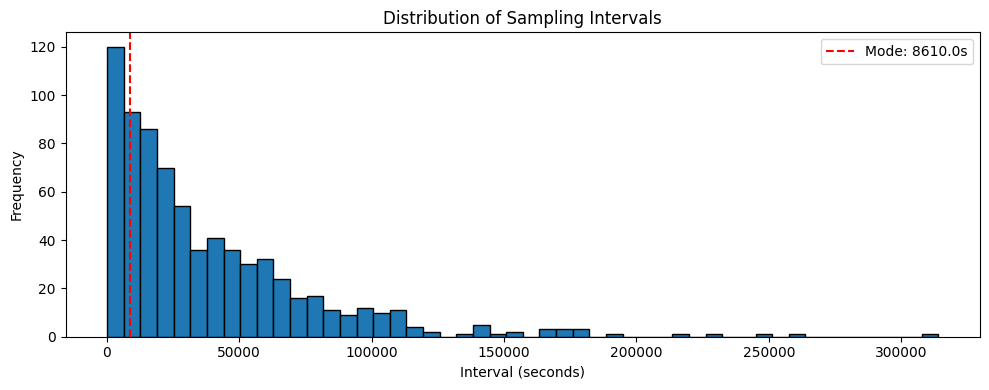

In [10]:
# Visualize interval distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.hist(intervals_array, bins=50, edgecolor='black')
plt.axvline(mode_interval, color='red', linestyle='--', label=f'Mode: {mode_interval}s')
plt.xlabel('Interval (seconds)')
plt.ylabel('Frequency')
plt.title('Distribution of Sampling Intervals')
plt.legend()
plt.tight_layout()
plt.show()

## Step 4: Data Completeness

In [11]:
print("=" * 60)
print("STEP 4: Checking Data Completeness")
print("=" * 60)

completeness_stats = {}

for col in ['cpu_util_percent', 'mem_util_percent', 'disk_io_percent', 'net_in', 'net_out']:
    valid = df[col].notna().sum()
    total = len(df)
    pct = valid / total * 100
    
    # Grade it
    if pct >= 95:
        grade = "A"
    elif pct >= 80:
        grade = "B"
    elif pct >= 60:
        grade = "C"
    else:
        grade = "D"
    
    completeness_stats[col] = {
        'valid_percent': round(pct, 1),
        'missing_percent': round(100 - pct, 1),
        'grade': grade,
    }
    
    print(f"  {col}: {pct:.1f}% valid (Grade {grade})")

# Overall assessment
cpu_ok = completeness_stats['cpu_util_percent']['valid_percent'] >= 80
mem_ok = completeness_stats['mem_util_percent']['valid_percent'] >= 80

if cpu_ok and mem_ok:
    overall = "GOOD - CPU and Memory data available"
elif cpu_ok or mem_ok:
    overall = "FAIR - Only partial data available"
else:
    overall = "POOR - Missing critical data"

completeness_stats['overall'] = overall
print(f"\nOverall: {overall}")

STEP 4: Checking Data Completeness
  cpu_util_percent: 100.0% valid (Grade A)
  mem_util_percent: 100.0% valid (Grade A)
  disk_io_percent: 99.3% valid (Grade A)
  net_in: 100.0% valid (Grade A)
  net_out: 100.0% valid (Grade A)

Overall: GOOD - CPU and Memory data available


## Step 5: Classify Containers for ML

In [12]:
print("=" * 60)
print("STEP 5: Classifying Containers for ML")
print("=" * 60)

# Get per-container statistics
container_stats = df.groupby('container_id').agg({
    'time_stamp': ['min', 'max', 'count'],
    'cpu_util_percent': lambda x: x.notna().sum() / len(x),
    'mem_util_percent': lambda x: x.notna().sum() / len(x),
})
container_stats.columns = ['ts_min', 'ts_max', 'record_count', 'cpu_completeness', 'mem_completeness']
container_stats['lifespan_hours'] = (container_stats['ts_max'] - container_stats['ts_min']) / 3600
container_stats['avg_completeness'] = (container_stats['cpu_completeness'] + container_stats['mem_completeness']) / 2

print(f"Computed stats for {len(container_stats):,} containers")

STEP 5: Classifying Containers for ML
Computed stats for 67,137 containers


In [13]:
# Tier classification function
def assign_tier(row):
    hours = row['lifespan_hours']
    records = row['record_count']
    complete = row['avg_completeness']
    
    if hours >= 168 and records >= 300 and complete >= 0.85:
        return 1  # Excellent
    elif hours >= 120 and records >= 200 and complete >= 0.75:
        return 2  # Very Good
    elif hours >= 72 and records >= 100 and complete >= 0.60:
        return 3  # Good
    elif hours >= 24 and records >= 40 and complete >= 0.50:
        return 4  # Fair
    elif hours >= 6 and records >= 15 and complete >= 0.40:
        return 5  # Marginal
    else:
        return 0  # Unsuitable

container_stats['tier'] = container_stats.apply(assign_tier, axis=1)

# Count tiers
tier_counts = container_stats['tier'].value_counts().sort_index()

tier_names = {
    0: 'Unsuitable',
    1: 'Excellent',
    2: 'Very Good',
    3: 'Good',
    4: 'Fair',
    5: 'Marginal'
}

print("\nTier Distribution:")
ml_candidates = {}
total = len(container_stats)

for tier in range(6):
    count = tier_counts.get(tier, 0)
    pct = count / total * 100
    print(f"  Tier {tier} ({tier_names[tier]:12s}): {count:,} ({pct:.1f}%)")
    ml_candidates[f'tier_{tier}'] = count


Tier Distribution:
  Tier 0 (Unsuitable  ): 33,499 (49.9%)
  Tier 1 (Excellent   ): 0 (0.0%)
  Tier 2 (Very Good   ): 0 (0.0%)
  Tier 3 (Good        ): 0 (0.0%)
  Tier 4 (Fair        ): 0 (0.0%)
  Tier 5 (Marginal    ): 33,638 (50.1%)


In [14]:
# ML pool assessment
ml_pool = tier_counts.get(1, 0) + tier_counts.get(2, 0) + tier_counts.get(3, 0)
ml_pool_estimated = int(ml_pool / SAMPLE_RATE)

if ml_pool_estimated > 100000:
    assessment = "EXCELLENT - Large ML training pool"
elif ml_pool_estimated > 10000:
    assessment = "GOOD - Sufficient for training"
elif ml_pool_estimated > 1000:
    assessment = "FAIR - Limited but usable"
else:
    assessment = "POOR - May need data augmentation"

ml_candidates['ml_pool_sampled'] = ml_pool
ml_candidates['ml_pool_estimated'] = ml_pool_estimated
ml_candidates['assessment'] = assessment

print(f"\nML Pool (Tier 1-3): {ml_pool:,} sampled, ~{format_number(ml_pool_estimated)} estimated")
print(f"Assessment: {assessment}")


ML Pool (Tier 1-3): 0 sampled, ~0 estimated
Assessment: POOR - May need data augmentation


In [15]:
# Save container stats for Phase 2
stats_path = os.path.join(OUTPUT_DIR, 'container_stats.csv')
container_stats.to_csv(stats_path)
print(f"Saved container stats: {stats_path}")

Saved container stats: ./phase1_output\container_stats.csv


## Step 6: Resource Statistics

In [16]:
print("=" * 60)
print("STEP 6: Resource Statistics")
print("=" * 60)

resource_stats = {}

for col, name in [('cpu_util_percent', 'CPU'), ('mem_util_percent', 'Memory')]:
    # Filter valid values (0-100%)
    data = df[col][(df[col] >= 0) & (df[col] <= 100)]
    
    stats = {
        'mean': round(data.mean(), 2),
        'median': round(data.median(), 2),
        'std': round(data.std(), 2),
        'min': round(data.min(), 2),
        'max': round(data.max(), 2),
        'p25': round(data.quantile(0.25), 2),
        'p75': round(data.quantile(0.75), 2),
        'p95': round(data.quantile(0.95), 2),
    }
    
    resource_stats[col] = stats
    
    print(f"\n{name}:")
    print(f"  Mean: {stats['mean']:.1f}%, Median: {stats['median']:.1f}%")
    print(f"  Std: {stats['std']:.1f}%")
    print(f"  Range: [{stats['min']:.1f}%, {stats['max']:.1f}%]")
    print(f"  IQR: [{stats['p25']:.1f}%, {stats['p75']:.1f}%]")

STEP 6: Resource Statistics

CPU:
  Mean: 9.5%, Median: 6.0%
  Std: 10.6%
  Range: [0.0%, 100.0%]
  IQR: [2.0%, 13.0%]

Memory:
  Mean: 80.7%, Median: 95.0%
  Std: 24.5%
  Range: [0.0%, 100.0%]
  IQR: [67.0%, 99.0%]


In [17]:
# CPU-Memory correlation
valid_data = df[(df['cpu_util_percent'].notna()) & (df['mem_util_percent'].notna())]
correlation = valid_data['cpu_util_percent'].corr(valid_data['mem_util_percent'])
resource_stats['cpu_mem_correlation'] = round(correlation, 4)

print(f"\nCPU-Memory Correlation: {correlation:.4f}")


CPU-Memory Correlation: 0.3577


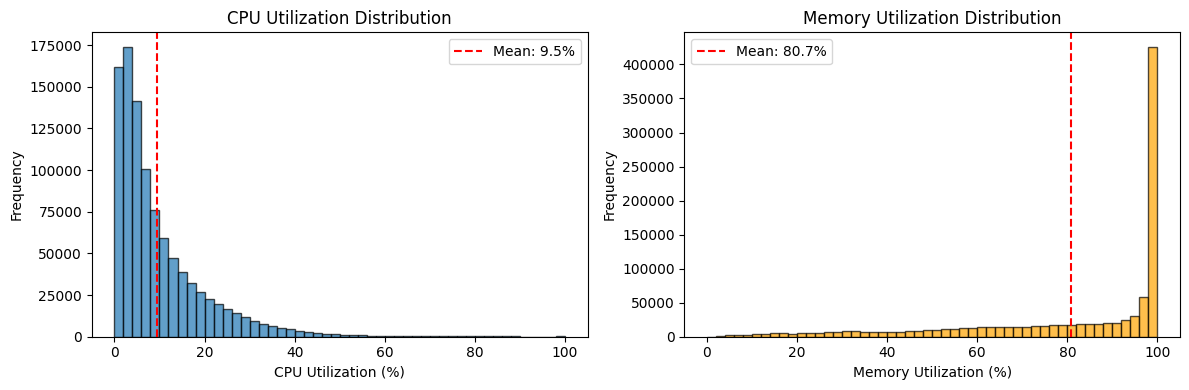

In [18]:
# Visualize distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# CPU distribution
cpu_data = df['cpu_util_percent'][(df['cpu_util_percent'] >= 0) & (df['cpu_util_percent'] <= 100)]
axes[0].hist(cpu_data, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(cpu_data.mean(), color='red', linestyle='--', label=f'Mean: {cpu_data.mean():.1f}%')
axes[0].set_xlabel('CPU Utilization (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('CPU Utilization Distribution')
axes[0].legend()

# Memory distribution
mem_data = df['mem_util_percent'][(df['mem_util_percent'] >= 0) & (df['mem_util_percent'] <= 100)]
axes[1].hist(mem_data, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(mem_data.mean(), color='red', linestyle='--', label=f'Mean: {mem_data.mean():.1f}%')
axes[1].set_xlabel('Memory Utilization (%)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Memory Utilization Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'resource_distributions.png'), dpi=150)
plt.show()

## Step 7: Generate Report & GO/NO-GO Decision

In [19]:
print("=" * 60)
print("PHASE 1: DATA PROFILING REPORT")
print("Alibaba Cluster Trace 2018")
print("=" * 60)
print(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Sample Rate: {SAMPLE_RATE*100}%")
print()

print("-" * 60)
print("1. DATASET OVERVIEW")
print("-" * 60)
print(f"Rows scanned:        {format_number(sampling_stats['total_rows_scanned'])}")
print(f"Rows sampled:        {format_number(sampling_stats['sampled_rows'])}")
print(f"Containers (est.):   {format_number(sampling_stats['containers_estimated'])}")
print(f"Time span:           {sampling_stats['time_range_days']:.1f} days")
print()

print("-" * 60)
print("2. SAMPLING INTERVALS")
print("-" * 60)
print(f"Mode interval:       {interval_stats['mode_seconds']} seconds")
print(f"Regularity:          {interval_stats['regularity_percent']}%")
print(f"Quality:             {interval_stats['quality']}")
print()

print("-" * 60)
print("3. DATA COMPLETENESS")
print("-" * 60)
for col in ['cpu_util_percent', 'mem_util_percent']:
    print(f"{col}: {completeness_stats[col]['valid_percent']}% (Grade {completeness_stats[col]['grade']})")
print(f"Overall: {completeness_stats['overall']}")
print()

print("-" * 60)
print("4. ML TRAINING POOL")
print("-" * 60)
print(f"ML Pool (sampled):   {ml_candidates['ml_pool_sampled']:,}")
print(f"ML Pool (estimated): {format_number(ml_candidates['ml_pool_estimated'])}")
print(f"Assessment:          {ml_candidates['assessment']}")
print()

print("-" * 60)
print("5. RESOURCE STATISTICS")
print("-" * 60)
for col in ['cpu_util_percent', 'mem_util_percent']:
    print(f"{col}:")
    print(f"  Mean: {resource_stats[col]['mean']}%, Median: {resource_stats[col]['median']}%")
print()

PHASE 1: DATA PROFILING REPORT
Alibaba Cluster Trace 2018
Generated: 2026-01-13 23:21:00
Sample Rate: 1.0%

------------------------------------------------------------
1. DATASET OVERVIEW
------------------------------------------------------------
Rows scanned:        100.0M
Rows sampled:        999.9K
Containers (est.):   6.1M
Time span:           8.0 days

------------------------------------------------------------
2. SAMPLING INTERVALS
------------------------------------------------------------
Mode interval:       8610.0 seconds
Regularity:          5.3%
Quality:             POOR - needs resampling

------------------------------------------------------------
3. DATA COMPLETENESS
------------------------------------------------------------
cpu_util_percent: 100.0% (Grade A)
mem_util_percent: 100.0% (Grade A)
Overall: GOOD - CPU and Memory data available

------------------------------------------------------------
4. ML TRAINING POOL
--------------------------------------------

In [20]:
# GO/NO-GO Decision
print("-" * 60)
print("6. GO/NO-GO DECISION")
print("-" * 60)

checks = []

# Check 1: ML pool sufficient
ml_pool_ok = ml_candidates['ml_pool_estimated'] > 1000
checks.append(("ML Pool > 1,000", ml_pool_ok))

# Check 2: Data quality
quality_ok = 'GOOD' in completeness_stats['overall'] or 'FAIR' in completeness_stats['overall']
checks.append(("Data Quality OK", quality_ok))

# Check 3: Time span
time_ok = sampling_stats['time_range_days'] >= 5
checks.append(("Time Span >= 5 days", time_ok))

passed = 0
for check_name, result in checks:
    status = "PASS" if result else "FAIL"
    print(f"  {check_name}: {status}")
    if result:
        passed += 1

print()
if passed == len(checks):
    decision = "GO - Proceed to Phase 2"
elif passed >= len(checks) - 1:
    decision = "CONDITIONAL GO - Proceed with caution"
else:
    decision = "NO-GO - Review data issues"

print(f">>> DECISION: {decision} <<<")
print("=" * 60)

------------------------------------------------------------
6. GO/NO-GO DECISION
------------------------------------------------------------
  ML Pool > 1,000: FAIL
  Data Quality OK: PASS
  Time Span >= 5 days: PASS

>>> DECISION: CONDITIONAL GO - Proceed with caution <<<


In [21]:
# Save all results
all_results = {
    'sampling': sampling_stats,
    'intervals': interval_stats,
    'completeness': completeness_stats,
    'ml_candidates': ml_candidates,
    'resources': resource_stats,
    'decision': decision,
}

results_path = os.path.join(OUTPUT_DIR, 'phase1_results.json')
with open(results_path, 'w') as f:
    json.dump(all_results, f, indent=2, default=str)

print(f"\nResults saved to: {results_path}")
print(f"\nOutput files in {OUTPUT_DIR}:")
for f in os.listdir(OUTPUT_DIR):
    print(f"  - {f}")


Results saved to: ./phase1_output\phase1_results.json

Output files in ./phase1_output:
  - container_stats.csv
  - phase1_results.json
  - resource_distributions.png
  - sampled_data.csv


## Next Steps

If the decision is **GO** or **CONDITIONAL GO**, proceed to:

**Phase 2: Data Preparation** (`Phase2_Data_Preparation.ipynb`)
- Resample to regular intervals
- Cluster containers by workload type
- Create train/val/test splits
- Feature engineering